# CCA: Canonical Correlation Analysis

Canonical Correlation Analysis or CCA is used to study the relationship between two sets of
variables which are measured on the same samples. One from each set, CCA finds pairs of linear combinations which are maximally
correlated. These are called canonical variates and they summarize the shared structure between the two
sets which is the strongest way in which they co-vary.


The result gives the canonical correlations and, for each side, the canonical
directions — recovered so that the resulting variates have unit variance.



In this documentation, we will depomstrate implementation of CCA using `BigRiverEssence.cca` on the `nutrimouse` dataset. 


## The method

Let us consider two centered data matrices $X$ (with $d_x$ variables) and $Y$ (with $d_y$ variables). They both have the same $n$ samples. CCA finds the direction vectors  $a$ and $b$ such that the correlation between the projected variates $a^\top X$ and $b^\top Y$ is maximized. Thus, consider the following optimization proble:  $$\max_{a,b} \; \operatorname{corr}(a^\top X, \, b^\top Y).$$ The first canonical pair obtained is the most correlated. After that each subsequent pair is the most
correlated subject to being uncorrelated with the previous ones. The strength of each pair is its canonical correlation and has a value in $[0,1]$.

Following Weenink 2003, `cca` solves this directly with the help of singular value decompositions of the two centered
data sets. This provides it with numerical stability. Since classical CCA estimates correlations from the data, it requires more samples than variables on either side. If this criteria is not met, the canonical correlations will trend spuriously toward 1. When the variable sets are wide, the sparse variant `scca` should be used instead.

The result gives the canonical correlations and, for each side, the canonical
directions — recovered so that the resulting variates have unit variance.

## The data

We use the `nutrimouse` dataset from the `mixOmics` package. It records $120$ liver gene
expression and $21$ lipid concentrations on the same $40$ mice.

In [ ]:
using BigRiverEssence, RCall, Plots, Statistics
const BRE = BigRiverEssence
gr()

R"""
suppressMessages(library(mixOmics))
data(nutrimouse)
genes  <- as.matrix(nutrimouse$gene)    # 40 × 120 liver gene expression
lipids <- as.matrix(nutrimouse$lipid)   # 40 × 21 lipid concentrations
"""
gene_full  = rcopy(R"genes")     # 40 × 120
lipid_full = rcopy(R"lipids")    # 40 × 21
size(gene_full), size(lipid_full)

((40, 120), (40, 21))

## Reducing to satisfy n > variables

As we discussed before, classical CCA ideally needs more samples than variables on either side. With only
$40$ mice, we cannot use all the $120$ genes. This will make the canonical correlations degenerate
toward $1$. To solve this problem, we only keep a small set on each side. We choose the $8$ most-variable genes and
lipids since they should carry the most signal.

It is important to note that `cca` also expects variables in rows and observations in columns. So after
subsetting we should transpose both blocks.


In [11]:
ngene, nlip = 8, 8               # keep 8 each ⇒ n = 40 > 8, 8 (stable)

gene_var  = vec(var(gene_full,  dims = 1))
lipid_var = vec(var(lipid_full, dims = 1))
gsel = sortperm(gene_var,  rev = true)[1:ngene]    # top-variance genes
lsel = sortperm(lipid_var, rev = true)[1:nlip]     # top-variance lipids

X = Matrix{Float64}(transpose(gene_full[:,  gsel]))   # 8 × 40  (genes × mice)
Y = Matrix{Float64}(transpose(lipid_full[:, lsel]))   # 8 × 40  (lipids × mice)
size(X), size(Y)

((8, 40), (8, 40))

With `n = 40` observations against `dx = dy = 8` variables, CCA is well-conditioned
and the stability warning in `cca` will not fire.

## Fitting the model

Now we fit `cca` to $X$ and $Y$ and note the cannonical correlations.




In [ ]:
m = BRE.cca(X, Y)                # :svd solver by default
m.corrs                          # canonical correlations, descending

8-element Vector{Float64}:
 0.9523239403367779
 0.9009956061552249
 0.7351224381011254
 0.6691906575873744
 0.45439712535338983
 0.2853836521130518
 0.20473098321451125
 0.19437273980817027

The fitted `ccaStructure` holds the means, the canonical directions for each side
(`xproj`, `yproj`), and the canonical correlations (`corrs`).

## The first canonical pair

If we project the mice onto the first canonical direction of each side using `cca_transform`, it will give us two scores
per mouse. Plotting one against the other will show us the shared structure CCA have found.


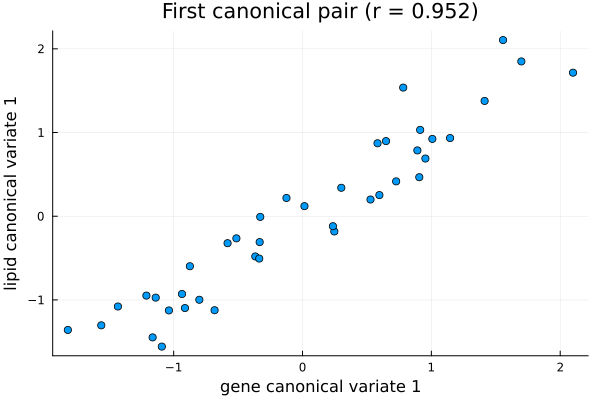

In [ ]:
Vx = BRE.cca_transform(m, X, :x)     # canonical variates, X side
Vy = BRE.cca_transform(m, Y, :y)     # canonical variates, Y side

scatter(Vx[1, :], Vy[1, :]; legend = false,
    xlabel = "gene canonical variate 1", ylabel = "lipid canonical variate 1",
    title = "First canonical pair (r = $(round(m.corrs[1], digits = 3)))")


In the above plot, each point is a mouse which is placed by its gene-side canonical score (horizontal) and its
lipid-side canonical score (vertical). Since CCA maximizes the correlation between
the two we can clearly see the points falling close to a line.  This
is the shared axis of variation: a particular combination of genes co-varies almost
perfectly with a particular combination of lipids across the 40 mice. We get a canonical correlation of about 0.95.


## The canonical correlations

We can see get a better look at the cannonical correlations by simply plotting them as a bar plot.

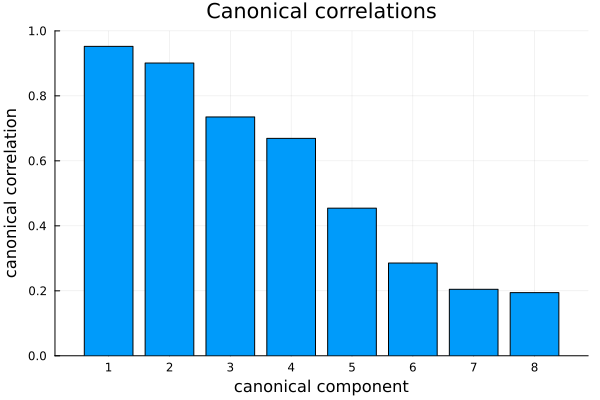

In [14]:
bar(m.corrs; legend = false, xticks = 1:length(m.corrs),
    xlabel = "canonical component", ylabel = "canonical correlation",
    title = "Canonical correlations", ylims = (0, 1))

We see in the above plot, the canonical correlations are descending from about $0.95$, with the first two pairs being strong
(with about  $0.95$ and $0.90$) and the rest tapering off. Like a scree plot, this shows us how many
canonical pairs carry real shared structure between the gene and lipid sets versus noise.

## Interpreting the canonical directions

The canonical directions reveal which variables drive the shared structure.

In [18]:
ene_names  = rcopy(R"colnames(genes)")[gsel]
lipid_names = rcopy(R"colnames(lipids)")[lsel]

@show [gene_names  m.xproj[:, 1]]      # gene direction 1: weight per selected gene
@show [lipid_names m.yproj[:, 1]]      # lipid direction 1: weight per selected lipid


[gene_names m.xproj[:, 1]] = Any["FAS" -0.03612315413104477; "CYP3A11" -2.859920042379921; "CYP4A14" -1.1981205496201077; "CYP4A10" -0.33120504566361286; "THIOL" 4.5751163719454935; "S14" 1.491641525077026; "G6Pase" -1.0398630182570934; "L.FABP" 1.2921988428035838]
[lipid_names m.yproj[:, 1]] = Any["C18.2n.6" -0.07691559277968146; "C18.1n.9" 0.039784264993113515; "C18.3n.3" -0.057176605167448; "C22.6n.3" -0.16348622122235598; "C20.4n.6" -0.010642862863773306; "C16.0" 0.04792819647372898; "C18.1n.7" 0.03926258225382172; "C16.1n.7" -0.24200896203957523]


8×2 Matrix{Any}:
 "C18.2n.6"  -0.0769156
 "C18.1n.9"   0.0397843
 "C18.3n.3"  -0.0571766
 "C22.6n.3"  -0.163486
 "C20.4n.6"  -0.0106429
 "C16.0"      0.0479282
 "C18.1n.7"   0.0392626
 "C16.1n.7"  -0.242009

We see that, on the gene side, THIOL, S14, and L.FABP (positive) together with CYP3A11 and CYP4A14
(negative) dominate the first component. On the other hand, on the lipid side, C16.1n.7 and C22.6n.3
contribute most. These are lipid-metabolism genes and fatty acids, so the first
canonical pair captures a genuine biological link between hepatic gene expression and lipid composition.


## Summary

In this document we used `cca` to find, given liver gene expression and lipid concentrations on the same $40$ mice, pairs of gene and lipid combinations that co-vary. We found the first correlated pair correlated at about $0.95$, driven by recognizable lipid-metabolism genes and fatty acids. 

In [ ]:
using BigRiverEssence, RCall, Plots, Statistics
const BRE = BigRiverEssence
gr()

R"""
suppressMessages(library(mixOmics))
data(nutrimouse)
genes  <- as.matrix(nutrimouse$gene)    # 40 × 120 liver gene expression
lipids <- as.matrix(nutrimouse$lipid)   # 40 × 21 lipid concentrations
"""
gene_full  = rcopy(R"genes")     # 40 × 120
lipid_full = rcopy(R"lipids")    # 40 × 21
size(gene_full), size(lipid_full)

((40, 120), (40, 21))

In [2]:
# Classical CCA needs n comfortably larger than the variable counts. With 40 mice,
# we keep a small set on each side: the most-variable genes and lipids carry the
# most signal, so we rank by variance and keep the top few.
ngene, nlip = 8, 8               # keep 8 each ⇒ n=40 > 8, 8 (stable)

gene_var  = vec(var(gene_full,  dims = 1))
lipid_var = vec(var(lipid_full, dims = 1))
gsel = sortperm(gene_var,  rev = true)[1:ngene]    # top-variance genes
lsel = sortperm(lipid_var, rev = true)[1:nlip]     # top-variance lipids

# cca wants variables in ROWS, observations in COLUMNS — so transpose after subsetting
X = Matrix{Float64}(transpose(gene_full[:,  gsel]))   # 8 × 40  (genes × mice)
Y = Matrix{Float64}(transpose(lipid_full[:, lsel]))   # 8 × 40  (lipids × mice)
size(X), size(Y)

((8, 40), (8, 40))

In [ ]:
m = BRE.cca(X, Y)                # :svd solver by default
m.corrs                          # the canonical correlations, descending

8-element Vector{Float64}:
 0.9523239403367779
 0.9009956061552249
 0.7351224381011254
 0.6691906575873744
 0.45439712535338983
 0.2853836521130518
 0.20473098321451125
 0.19437273980817027

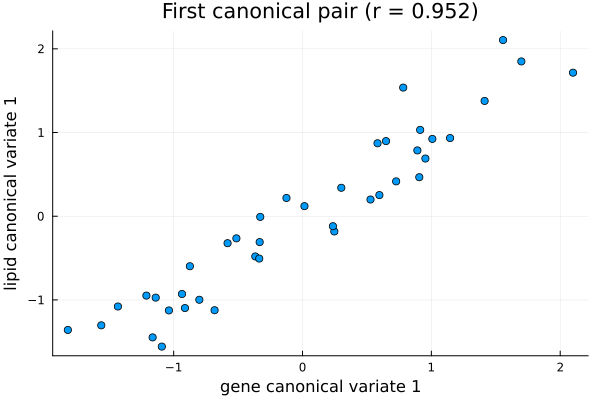

In [ ]:
# Project the mice onto the first canonical directions of each side, then plot the
# X-variate against the Y-variate. CCA maximizes their correlation, so the points
# should lie close to a line — that's the shared structure between genes and lipids.
Vx = BRE.cca_transform(m, X, :x)     # p × n canonical variates (X side)
Vy = BRE.cca_transform(m, Y, :y)     # p × n canonical variates (Y side)

scatter(Vx[1, :], Vy[1, :]; legend = false,
    xlabel = "gene canonical variate 1", ylabel = "lipid canonical variate 1",
    title = "First canonical pair (r = $(round(m.corrs[1], digits=3)))")

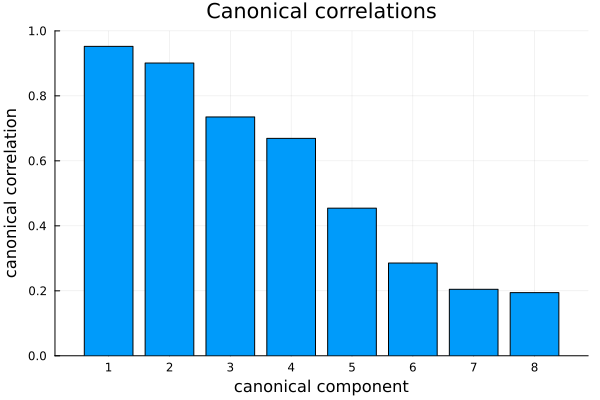

In [5]:
bar(m.corrs; legend = false, xticks = 1:length(m.corrs),
    xlabel = "canonical component", ylabel = "canonical correlation",
    title = "Canonical correlations", ylims = (0, 1))

In [ ]:
size(m.xproj), size(m.yproj)     # dx × p and dy × p canonical directions
m.corrs                          # canonical correlations

# which genes/lipids drive canonical pair 1? (the loading weights)
gene_names  = rcopy(R"colnames(genes)")[gsel]
lipid_names = rcopy(R"colnames(lipids)")[lsel]
@show [gene_names m.xproj[:, 1]]       # gene direction 1: weights per selected gene
@show [lipid_names m.yproj[:, 1]]      # lipid direction 1: weights per selected lipid

[gene_names m.xproj[:, 1]] = Any["FAS" -0.03612315413104477; "CYP3A11" -2.859920042379921; "CYP4A14" -1.1981205496201077; "CYP4A10" -0.33120504566361286; "THIOL" 4.5751163719454935; "S14" 1.491641525077026; "G6Pase" -1.0398630182570934; "L.FABP" 1.2921988428035838]
[lipid_names m.yproj[:, 1]] = Any["C18.2n.6" -0.07691559277968146; "C18.1n.9" 0.039784264993113515; "C18.3n.3" -0.057176605167448; "C22.6n.3" -0.16348622122235598; "C20.4n.6" -0.010642862863773306; "C16.0" 0.04792819647372898; "C18.1n.7" 0.03926258225382172; "C16.1n.7" -0.24200896203957523]


8×2 Matrix{Any}:
 "C18.2n.6"  -0.0769156
 "C18.1n.9"   0.0397843
 "C18.3n.3"  -0.0571766
 "C22.6n.3"  -0.163486
 "C20.4n.6"  -0.0106429
 "C16.0"      0.0479282
 "C18.1n.7"   0.0392626
 "C16.1n.7"  -0.242009